<a href="https://colab.research.google.com/github/MuhammadFarhan96/AiML-Project/blob/main/IMDb_Movie_Review_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping

In [9]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

In [10]:
print("Training Samples =", len(X_train))
print("Testing Samples =", len(X_test))

print("\nFirst Review=")
print(X_train[0])

print("\nFirst Label=")
print(y_train[0])

Training Samples = 25000
Testing Samples = 25000

First Review=
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 

In [11]:
max_length = 200

X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [12]:
model = Sequential()

model.add(Embedding(vocab_size,128,input_length=max_length))

model.add(LSTM(128))

model.add(Dense(64,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

In [28]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,259,717 (16.25 MB)

 Trainable params: 1,419,905 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,839,812 (10.83 MB)

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 172s 540ms/step - accuracy: 0.5314 - loss: 0.6915 - val_accuracy: 0.5582 - val_loss: 0.6763
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 201s 538ms/step - accuracy: 0.5623 - loss: 0.6719 - val_accuracy: 0.5120 - val_loss: 0.6966
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 160s 512ms/step - accuracy: 0.6298 - loss: 0.6114 - val_accuracy: 0.6042 - val_loss: 0.6696
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 161s 513ms/step - accuracy: 0.6719 - loss: 0.5900 - val_accuracy: 0.7800 - val_loss: 0.5554
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 161s 512ms/step - accuracy: 0.8324 - loss: 0.4059 - val_accuracy: 0.8292 - val_loss: 0.4166
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 160s 511ms/step - accuracy: 0.8880 - loss: 0.2841 - val_accuracy: 0.8362 - val_loss: 0.3868
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 159s 510ms/step - accuracy: 0.9209 - loss: 0.2140 - val_accuracy: 0.8536 - val_loss: 0.4086
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 211s 539ms/step - accuracy: 0.9464 -

In [15]:
loss,accuracy = model.evaluate(
    X_test,
    y_test
)

print("Loss =",loss)
print("Accuracy =",accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 103ms/step - accuracy: 0.8181 - loss: 1.2494
Loss = 1.2494449615478516
Accuracy = 0.8180800080299377


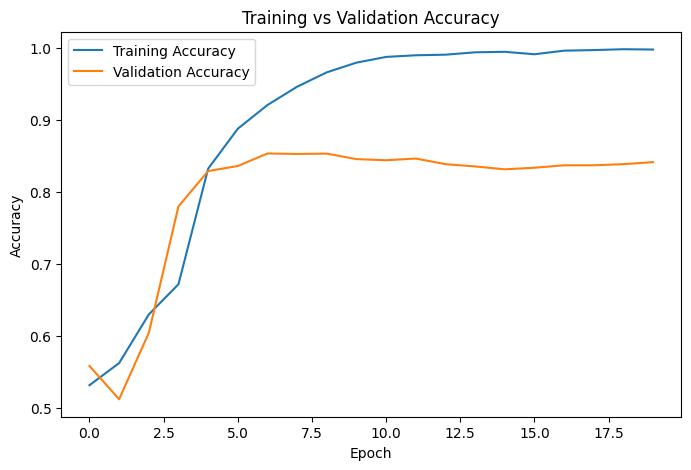

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')

plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

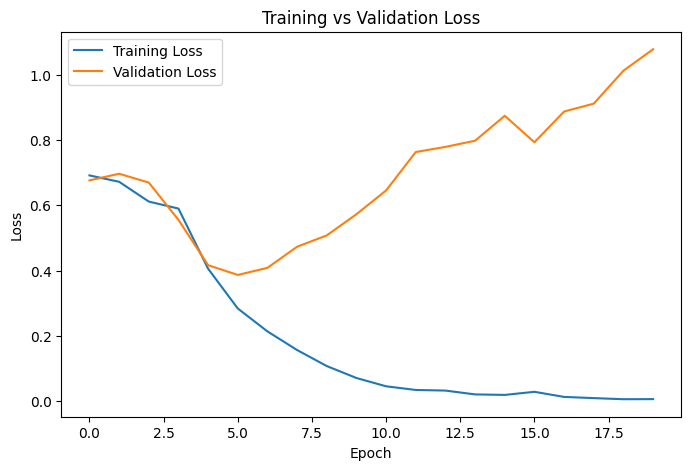

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')

plt.plot(history.history['val_loss'],label='Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [18]:
model = Sequential()

model.add(Embedding(vocab_size,128,input_length=max_length))

model.add(LSTM(128))

model.add(Dropout(0.3))

model.add(Dense(64,activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(1,activation='sigmoid'))

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 164s 523ms/step - accuracy: 0.9198 - loss: 0.2294 - val_accuracy: 0.8462 - val_loss: 0.4092
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 198s 509ms/step - accuracy: 0.9397 - loss: 0.1812 - val_accuracy: 0.8460 - val_loss: 0.4230
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 170s 545ms/step - accuracy: 0.9567 - loss: 0.1392 - val_accuracy: 0.8342 - val_loss: 0.4943


In [25]:
loss,accuracy = model.evaluate(
    X_test,
    y_test
)

print("Loss =",loss)
print("Accuracy =",accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.8358 - loss: 0.4344
Loss = 0.43441042304039
Accuracy = 0.8357599973678589


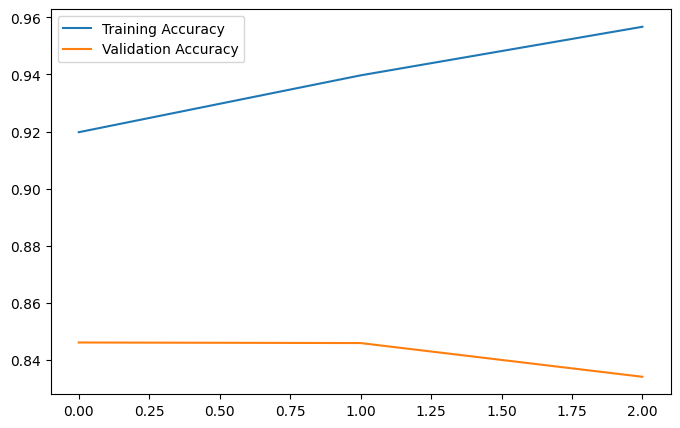

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')

plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.legend()

plt.show()

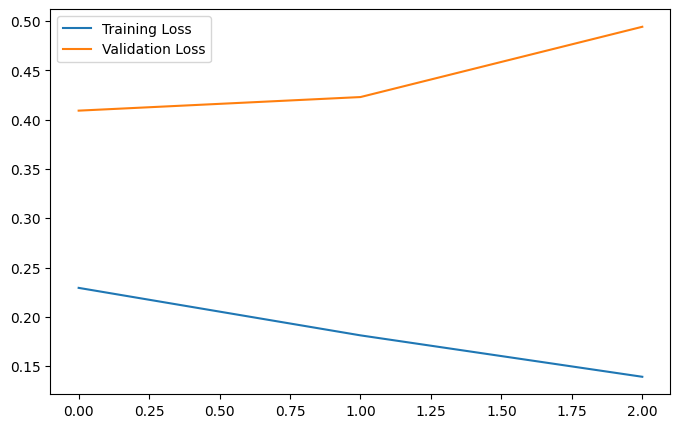

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')

plt.plot(history.history['val_loss'],label='Validation Loss')

plt.legend()

plt.show()